In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.image as mpimg 
import cv2
import os

In [2]:
print(os.listdir('TB_Chest_Radiography_Database/Normal/'))

['Normal-1.png', 'Normal-10.png', 'Normal-100.png', 'Normal-1000.png', 'Normal-1001.png', 'Normal-1002.png', 'Normal-1003.png', 'Normal-1004.png', 'Normal-1005.png', 'Normal-1006.png', 'Normal-1007.png', 'Normal-1008.png', 'Normal-1009.png', 'Normal-101.png', 'Normal-1010.png', 'Normal-1011.png', 'Normal-1012.png', 'Normal-1013.png', 'Normal-1014.png', 'Normal-1015.png', 'Normal-1016.png', 'Normal-1017.png', 'Normal-1018.png', 'Normal-1019.png', 'Normal-102.png', 'Normal-1020.png', 'Normal-1021.png', 'Normal-1022.png', 'Normal-1023.png', 'Normal-1024.png', 'Normal-1025.png', 'Normal-1026.png', 'Normal-1027.png', 'Normal-1028.png', 'Normal-1029.png', 'Normal-103.png', 'Normal-1030.png', 'Normal-1031.png', 'Normal-1032.png', 'Normal-1033.png', 'Normal-1034.png', 'Normal-1035.png', 'Normal-1036.png', 'Normal-1037.png', 'Normal-1038.png', 'Normal-1039.png', 'Normal-104.png', 'Normal-1040.png', 'Normal-1041.png', 'Normal-1042.png', 'Normal-1043.png', 'Normal-1044.png', 'Normal-1045.png', 'N

In [3]:
img = cv2.imread('TB_Chest_Radiography_Database/Normal/Normal-1065.png')

In [4]:
img.shape

(512, 512, 3)

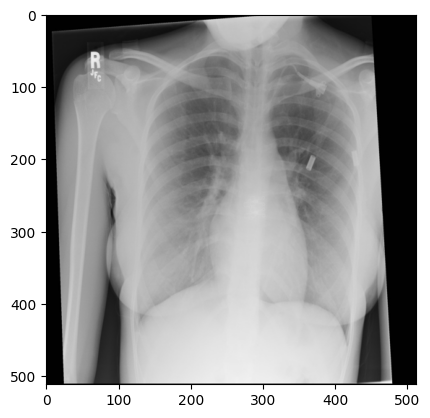

In [5]:
plt.imshow(img)

In [6]:
labels = {
    'Normal': 0,
    'Tuberculosis': 1
}

In [7]:
X = []
y = []

for i in os.listdir('TB_Chest_Radiography_Database/'):
    for j in os.listdir(f'TB_Chest_Radiography_Database/{i}/'):
        image = cv2.imread(f'TB_Chest_Radiography_Database/{i}/{j}')
        image = cv2.resize(image, (120, 120))
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        image = image.reshape(120, 120, 1)
        image = image / 255
        X.append(image)
        y.append(labels[i])

X = np.array(X)
y = np.array(y)

In [8]:
X.shape

(4200, 120, 120, 1)

In [9]:
y.shape

(4200,)

In [10]:
from sklearn.utils import shuffle

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)

In [14]:
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Dropout, Flatten
from keras.optimizers import Adam

In [15]:
model = Sequential()

model.add(Conv2D(filters=32, kernel_size=(3, 3), input_shape=(120, 120, 1), padding='same', activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D())
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(units=256, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=64, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(units=32, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))

C:\Users\Zhores\Desktop\MLOps\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

In [17]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=64, epochs=20)

Epoch 1/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 186ms/step - accuracy: 0.8119 - loss: 0.5256 - val_accuracy: 0.8369 - val_loss: 0.4282
Epoch 2/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 178ms/step - accuracy: 0.8318 - loss: 0.4566 - val_accuracy: 0.8369 - val_loss: 0.3932
Epoch 3/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 177ms/step - accuracy: 0.8435 - loss: 0.3517 - val_accuracy: 0.9012 - val_loss: 0.2411
Epoch 4/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - accuracy: 0.9101 - loss: 0.2358 - val_accuracy: 0.9214 - val_loss: 0.1979
Epoch 5/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 176ms/step - accuracy: 0.9301 - loss: 0.1884 - val_accuracy: 0.9417 - val_loss: 0.1338
Epoch 6/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 175ms/step - accuracy: 0.9476 - loss: 0.1509 - val_accuracy: 0.9476 - val_loss: 0.1206
Epoch 7/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 10s 181ms/step - accuracy: 0.9557 - loss: 0.1360 - val_accuracy: 0.9702 - val_loss: 0.0908
Epoch 8/20
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 177ms/step - accuracy: 0.9649 - loss: 0.1100 - val_accuracy: 

In [18]:
new_image = mpimg.imread('hivand.jpg')
new_image = cv2.resize(new_image, (120, 120))
new_image = cv2.cvtColor(new_image, cv2.COLOR_BGR2GRAY)
new_image = new_image.reshape(1, 120, 120, 1)
new_image = new_image / 255

pred = model.predict(new_image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


In [19]:
print(pred)

[[0.9998103]]
